<a href="https://colab.research.google.com/github/akriti404/Deep-Learning-Lab/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#CNN for MNIST Dataset
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader,Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

# CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1), # -> 32 x 28 x 28
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                              # -> 32 x 14 x 14

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), # -> 64 x 14 x 14
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)                               # -> 64 x 7 x 7
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10) # 10 output classes (digits 0-9)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 3

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device) #to move from main memory
       # to device memory
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\nAccuracy on 10,000 test images: {100 * correct / total:.2f}%")

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 21.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 610kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.86MB/s]


Epoch [1/3], Loss: 0.1530
Epoch [2/3], Loss: 0.0490
Epoch [3/3], Loss: 0.0361

Accuracy on 10,000 test images: 98.99%


100%|██████████| 26.4M/26.4M [00:01<00:00, 15.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 231kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.29MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.7MB/s]



=== Running: 1. Baseline WITHOUT Data Augmentation ===
Epoch 01/40 | Train Loss: 0.4418 (Acc: 82.0%) | Val Loss: 0.1047 (Acc: 99.3%)
Epoch 10/40 | Train Loss: 0.0000 (Acc: 100.0%) | Val Loss: 0.0133 (Acc: 99.6%)
Epoch 20/40 | Train Loss: 0.0000 (Acc: 100.0%) | Val Loss: 0.0136 (Acc: 99.6%)
Epoch 30/40 | Train Loss: 0.0000 (Acc: 100.0%) | Val Loss: 0.0137 (Acc: 99.6%)
Epoch 40/40 | Train Loss: 0.0000 (Acc: 100.0%) | Val Loss: 0.0137 (Acc: 99.6%)

=== Running: 2. Fixed WITH torchvision Data Augmentation ===
Epoch 01/40 | Train Loss: 0.5776 (Acc: 64.0%) | Val Loss: 0.2899 (Acc: 94.3%)
Epoch 10/40 | Train Loss: 0.0406 (Acc: 98.0%) | Val Loss: 0.0340 (Acc: 98.8%)
Epoch 20/40 | Train Loss: 0.0178 (Acc: 100.0%) | Val Loss: 0.0453 (Acc: 98.5%)
Epoch 30/40 | Train Loss: 0.0031 (Acc: 100.0%) | Val Loss: 0.0360 (Acc: 98.8%)
Epoch 40/40 | Train Loss: 0.0032 (Acc: 100.0%) | Val Loss: 0.0177 (Acc: 99.3%)


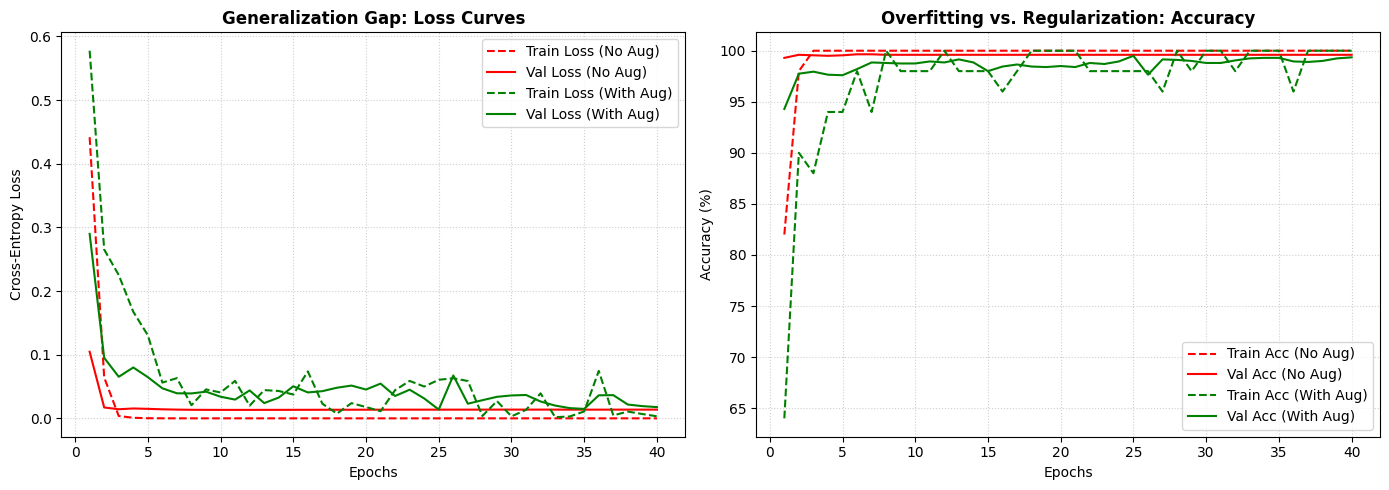

In [2]:
# Set seed for exact reproducibility across runs
torch.manual_seed(42)
# Target Application: Defect Identification (Binary Classification)
# We map FashionMNIST classes to:
#   0: "Pass" (e.g., T-shirt/top)
#   1: "Defective" (e.g., Ankle boot - structural mismatch)

# Transformation for baseline (No Augmentation - raw tensors only)
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train = datasets.FashionMNIST(root='./data', train=True, download=True, transform=base_transform)
full_test = datasets.FashionMNIST(root='./data', train=False, download=True, transform=base_transform)

def filter_binary(dataset):
    indices = [i for i, (_, label) in enumerate(dataset) if label in [0, 9]]
    # Remap label 9 to 1 for binary cross-entropy simplicity
    for i in indices:
        dataset.targets[i] = 1 if dataset.targets[i] == 9 else 0
    return Subset(dataset, indices)

binary_train = filter_binary(full_train)
binary_test = filter_binary(full_test)

# induce overfitting
tiny_train_subset = Subset(binary_train, range(50))


train_loader_no_aug = DataLoader(tiny_train_subset, batch_size=10, shuffle=True)
test_loader = DataLoader(binary_test, batch_size=64, shuffle=False)

# Augmentation pipeline to simulate physical variations
aug_transform = transforms.Compose([
    transforms.RandomRotation(degrees=15),          # Camera alignment jitter
    transforms.RandomHorizontalFlip(p=0.5),         # Component orientation shift
    transforms.RandomResizedCrop(28, scale=(0.8, 1.0)), # Distance/zoom variations
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Re-instantiate raw dataset with Augmentation transform applied
full_train_aug = datasets.FashionMNIST(root='./data', train=True, download=False, transform=aug_transform)
binary_train_aug = filter_binary(full_train_aug)
tiny_train_aug_subset = Subset(binary_train_aug, range(50))

train_loader_aug = DataLoader(tiny_train_aug_subset, batch_size=10, shuffle=True)

class DefectClassifier(nn.Module):
    def __init__(self):
        super(DefectClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

def train_and_evaluate(train_loader, test_loader, title="Experiment", epochs=40, lr=0.001):
    model = DefectClassifier()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    print(f"\n=== Running: {title} ===")

    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for bx, by in train_loader:
            optimizer.zero_grad()
            outputs = model(bx)
            loss = criterion(outputs, by)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * bx.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == by).sum().item()
            total += by.size(0)

        epoch_train_loss = running_loss / total
        epoch_train_acc = 100 * correct / total
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        # Validation
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for bx, by in test_loader:
                outputs = model(bx)
                loss = criterion(outputs, by)
                val_running_loss += loss.item() * bx.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == by).sum().item()
                val_total += by.size(0)

        epoch_val_loss = val_running_loss / val_total
        epoch_val_acc = 100 * val_correct / val_total
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d}/{epochs} | Train Loss: {epoch_train_loss:.4f} (Acc: {epoch_train_acc:.1f}%) | "
                  f"Val Loss: {epoch_val_loss:.4f} (Acc: {epoch_val_acc:.1f}%)")

    return train_losses, val_losses, train_accs, val_accs
torch.manual_seed(42)
t_loss_no_aug, v_loss_no_aug, t_acc_no_aug, v_acc_no_aug = train_and_evaluate(
    train_loader_no_aug, test_loader, title="1. Baseline WITHOUT Data Augmentation"
)

torch.manual_seed(42)
t_loss_aug, v_loss_aug, t_acc_aug, v_acc_aug = train_and_evaluate(
    train_loader_aug, test_loader, title="2. Fixed WITH torchvision Data Augmentation"
)

epochs_range = range(1, 41)
plt.figure(figsize=(14, 5))

# Plot 1: Loss Curves (Generalization Gap)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, t_loss_no_aug, 'r--', label='Train Loss (No Aug)')
plt.plot(epochs_range, v_loss_no_aug, 'r-', label='Val Loss (No Aug)')
plt.plot(epochs_range, t_loss_aug, 'g--', label='Train Loss (With Aug)')
plt.plot(epochs_range, v_loss_aug, 'g-', label='Val Loss (With Aug)')
plt.title('Generalization Gap: Loss Curves', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 2: Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(epochs_range, t_acc_no_aug, 'r--', label='Train Acc (No Aug)')
plt.plot(epochs_range, v_acc_no_aug, 'r-', label='Val Acc (No Aug)')
plt.plot(epochs_range, t_acc_aug, 'g--', label='Train Acc (With Aug)')
plt.plot(epochs_range, v_acc_acc := v_acc_aug, 'g-', label='Val Acc (With Aug)')
plt.title('Overfitting vs. Regularization: Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()